# Imports

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from functools import reduce
from tqdm import tqdm
import re

# Load and Merge all Datasets

Loading Book Sales and Metadata

In [6]:
# Load books metadata
book_info = pd.read_csv("Books_Metadata.csv")
book_info["Title_clean"] = book_info["Title"].str.strip().str.lower()

# Load books sales data from 2020 to 2024
sales_dfs = []
sales_book_name = "Назва"

for year in range(2020, 2025):
    file_path = f"Books_Monthly_Sales_{year}.xlsx"
    df_year = pd.read_excel(file_path, skiprows=6)

    # Rename all monthly columns to month_year style
    df_year.rename(columns={
        col: f"{col}_{year}" for col in df_year.columns if col != sales_book_name
    }, inplace=True)

    sales_dfs.append(df_year)

# Merge all years together
all_sales = reduce(lambda left, right: pd.merge(left, right, on=sales_book_name, how="outer"), sales_dfs)
all_sales["Book_clean"] = all_sales[sales_book_name].astype(str).str.strip().str.lower()


Merging Book Sales with Metadata

In [9]:
# Fuzzy searching and matching
match_dict = {}

for i, sale_row in tqdm(all_sales.iterrows(), total=len(all_sales), desc="Matching Titles"):
    sale_title = str(sale_row["Book_clean"]).strip().lower()

    best_match = None
    best_score = 0

    for info_title_raw in book_info["Title_clean"]:
        info_title = str(info_title_raw).strip().lower()

        if info_title and sale_title:
            if info_title in sale_title or sale_title in info_title:
                score = len(info_title) / len(sale_title) if len(sale_title) > 0 else 0
                if score > best_score:
                    best_score = score
                    best_match = info_title

    if best_match and best_match not in match_dict.values():
        match_dict[sale_row["Book_clean"]] = best_match

match_df = pd.DataFrame.from_dict(match_dict, orient="index", columns=["matched_title"]).reset_index()
match_df.rename(columns={"index": "Book_clean"}, inplace=True)

# Combining matched title with sales data
matched_sales = pd.merge(all_sales, match_df, on="Book_clean", how="inner")

# Remove duplicate titles
matched_sales = matched_sales.drop_duplicates(subset=["matched_title"])

# Combining matched title with books metadata
merged = pd.merge(matched_sales, book_info, left_on="matched_title", right_on="Title_clean", how="inner")
merged.drop(columns=["Book_clean", "Title_clean", "matched_title"], inplace=True)

Matching Titles: 100%|██████████| 1555/1555 [00:02<00:00, 570.30it/s]


Merging Print_Run Dataset with Book Sales and Metadata

In [10]:
# Load data print-run information
main_data = merged
archive = pd.read_excel("Books_Print_Run_Info.xlsx")
main_data["Title_clean"] = main_data["Title"].astype(str).str.strip().str.lower()
archive["Title_clean"] = archive["Назва"].astype(str).str.strip().str.lower()

# Summing up print-runs for books with more than one print-run info row
archive_grouped = archive.groupby("Title_clean", as_index=False).agg({
    "Тираж": "sum",
    "Друкарня": lambda x: x.mode().iloc[0] if not x.mode().empty else x.iloc[0]
})

# # === STEP 4: Drop existing 'Тираж' and 'Друкарня' from main_data (safe) ===
# main_data = main_data.drop(columns=["Тираж", "Друкарня"], errors='ignore')

# Datasets Merge
merged = pd.merge(main_data, archive_grouped, on="Title_clean", how="inner")
merged.drop(columns=["Title_clean"], inplace=True)


Cleaning Data

In [11]:
# Convert sales columns to numeric and replace empty strings with NaN
years = ["2020", "2021", "2022", "2023", "2024"]
sales_cols = [col for col in merged.columns if any(year in col for year in years)]

for col in sales_cols:
    merged[col] = pd.to_numeric(merged[col], errors='coerce')
    merged[col] = merged[col].replace("", np.nan)

# Drop rows with no sales or unnamed columns
df_cleaned = merged.dropna(subset=sales_cols, how="all")
df_cleaned = df_cleaned.drop(columns=[col for col in df_cleaned.columns if "Unnamed" in col], errors='ignore')
df_cleaned.reset_index(drop=True, inplace=True)
df_cleaned = df_cleaned.dropna(axis=1, how='all')

# Save cleaned dataset
df_cleaned.to_csv("merged_book_sales_cleaned.csv", index=False)

# Feature Engineering

Creating additional features based on description for classification

In [14]:
df = pd.read_csv("merged_book_sales_cleaned.csv")
df = df[df["Title"].fillna("").str.strip() != ""]
df.reset_index(drop=True, inplace=True)
df["Text"] = (df["Title"].fillna("") + " " + df["Description"].fillna("")).str.lower()

# Target Audience
def get_target_audience(text):
    if any(w in text for w in ["дитина", "казка", "малюк", "абетка", "школа", "дитячий", "вірш"]):
        return "Children"
    if any(w in text for w in ["молодь", "підліток", "зрілість", "дорослішання"]):
        return "Teenagers"
    if any(w in text for w in ["подружжя", "шлюб", "виховання", "родина", "батьки", "мати"]):
        return "Family"
    if any(w in text for w in ["душа", "молитва", "покаяння", "таїнство", "піст", "богослов", "служіння"]):
        return "Adults"
    return "General"

# Biblical Reference Level
def classify_biblical_level(text):
    high_roots = [
        "біблі", "євангел", "святе письмо", "псалм", "псалтир", "пророк", "апостол",
        "тлумачен", "коментар", "старий завіт", "новий завіт", "богослов", "юдей", "слово боже"
    ]
    medium_roots = [
        "притч", "роздум", "заповід", "святий", "катехизм", "духовн", "повчан", "доктрин", "догма"
    ]
    low_roots = [
        "мораль", "мудр", "цінн", "щаст", "краса", "любов", "натхнен", "емоці", "розвиток", "поради"
    ]
    extra_high = ["господь", "ісус", "христос", "спаситель", "учні", "воскресіння", "сповідь"]
    extra_medium = ["чесноти", "світогляд", "християнськ", "віровчення"]

    high_score = sum(1 for root in high_roots if re.search(root, text))
    medium_score = sum(1 for root in medium_roots if re.search(root, text))
    low_score = sum(1 for root in low_roots if re.search(root, text))

    high_score += sum(1 for i in extra_high if i in text)
    medium_score += sum(1 for i in extra_medium if i in text)

    if high_score >= max(medium_score, low_score) and high_score > 0:
        return "High"
    elif medium_score >= max(high_score, low_score) and medium_score > 0:
        return "Medium"
    elif low_score > 0:
        return "Low"
    else:
        return "Very Low"

# Application Type
def get_application_type(text):
    if any(w in text for w in ["день", "роздуми"]):
        return "Daily Prayers"
    if any(w in text for w in ["вивчення", "уроки", "курс", "тлумачення"]):
        return "Studies"
    if any(w in text for w in ["біографія", "житія", "історія життя"]):
        return "Biography"
    if any(w in text for w in ["молитви", "молитовник", "прохання", "молебень", "акафісник"]):
        return "Prayers"
    if any(w in text for w in ["казка", "повість", "розповідь"]):
        return "Tales"
    return "General"

# Event Relevance
def get_event_relevance(text):
    if any(w in text for w in ["різдво", "новий рік", "коляда"]):
        return "Christmas"
    if "великдень" in text:
        return "Easter"
    if any(w in text for w in ["піст", "страсті", "страсна"]):
        return "Fasting"
    if any(w in text for w in ["випуск", "школа", "навчання"]):
        return "School Time"
    return "No Event"

# Content Format
def get_content_format(text):
    if any(w in text for w in ["поезія", "вірш", "вірші"]):
        return "Poetry"
    if any(w in text for w in ["оповідання", "повість", "розповідь", "притча"]):
        return "Stories"
    if any(w in text for w in ["молитва", "акафісник", "піснеспів"]):
        return "Prayer"
    if any(w in text for w in ["лист", "діалог"]):
        return "Dialogue/Letters"
    return "Prose"

# Add columns to Dataframe
df["Target Audience"] = df["Text"].apply(get_target_audience)
df["Biblical Level"] = df["Text"].apply(classify_biblical_level)
df["Application Type"] = df["Text"].apply(get_application_type)
df["Event Relevance"] = df["Text"].apply(get_event_relevance)
df["Content Format"] = df["Text"].apply(get_content_format)


df.drop(columns=["Text"], inplace=True)

Add Author Score feature

In [15]:
# Calculate Author Score (number of books per author)
author_counts = df["Author"].value_counts()
df["Author Score"] = df["Author"].map(author_counts).fillna(0).astype(int)

# Add Author Score to Dataframe
cols = list(df.columns)
author_idx = cols.index("Author")
cols.insert(author_idx + 1, cols.pop(cols.index("Author Score")))
df = df[cols]

# Prepare Data for Classification

Remove negative sales and count total sales per book

In [16]:
# Identify sales columns
years = ["2020", "2021", "2022", "2023", "2024"]
sales_cols = [col for col in df.columns if any(year in col for year in years)]

# Replace negative sales values with 0
for col in sales_cols:
    df[col] = df[col].apply(lambda x: x if pd.isna(x) else (x if x >= 0 else 0))

# Add Total Sales column
df["Total_Sales"] = df[sales_cols].sum(axis=1)

Count and add Succes Rate

In [17]:
# Count Success Rate
df["Price"] = (
    df["Price"].astype(str)
    .str.replace("грн.", "", regex=False)
    .str.replace(",", ".", regex=False)
    .str.extract(r"(\d+\.?\d*)")[0]
    .astype(float)
)

df["Success_Rate"] = (df["Total_Sales"] / df["Тираж"]).fillna(0) * 100

# Remove books with more than 100% sales
df = df[df["Success_Rate"] <= 100].copy()
df["Success_Rate"] = np.ceil(df["Success_Rate"]).astype(int)

# Save final dataset for classification models
df.to_csv("final_books_for_classification.csv", index=False)

# Prepare Data for Sales Forecasting

Change wide-format dataset to long-format

In [18]:
df = pd.read_csv("final_books_for_classification.csv")
sales_cols = [col for col in df.columns if any(str(y) in col for y in range(2020, 2025))]
book_cols = ['Title', 'Author', 'Author Score', 'Production_Year', 'Price', 'Pages']

# Melting to long-format with each row representing one sales month
df_long = df.melt(id_vars=book_cols, value_vars=sales_cols,
                  var_name="Month_Year", value_name="Sales")

df_long[["Month_Name", "Sales_Year"]] = df_long["Month_Year"].str.extract(r"([А-Яа-яA-Za-z]+)_(\d+)")
df_long["Sales_Year"] = df_long["Sales_Year"].astype(int)

month_map = {
    "сіень": 1, "лютий": 2, "березень": 3, "квітень": 4,
    "травень": 5, "червень": 6, "липень": 7, "серпень": 8,
    "вересень": 9, "жовтень": 10, "листопад": 11, "грудень": 12
}
df_long["Month_Num"] = df_long["Month_Name"].str.lower().map(month_map)

df_long["Date"] = pd.to_datetime(dict(year=df_long["Sales_Year"],
                                      month=df_long["Month_Num"],
                                      day=1), errors='coerce')

# Clean numeric columns
df_long["Sales"] = pd.to_numeric(df_long["Sales"], errors='coerce')
df_long["Price"] = df_long["Price"].astype(str).str.replace("грн.", "", regex=False).str.replace(",", ".")
df_long["Price"] = df_long["Price"].str.extract(r"(\d+\.?\d*)")[0].astype(float)

df_long.dropna(subset=["Date", "Sales"], inplace=True)

# Create full monthly grid
all_months = pd.date_range("2020-01-01", "2024-12-01", freq="MS")
titles = df_long["Title"].unique()
full_index = pd.MultiIndex.from_product([titles, all_months], names=["Title", "Date"])
df_full = pd.DataFrame(index=full_index).reset_index()

df_merged = pd.merge(df_full, df_long, on=["Title", "Date"], how="left")

# Add back metadata per book
meta_cols = ['Author', 'Author Score', 'Production_Year', 'Price', 'Pages']
df_merged.sort_values(["Title", "Date"], inplace=True)
df_merged[meta_cols] = df_merged.groupby("Title")[meta_cols].ffill().bfill()

df_merged["Month"] = df_merged["Date"].dt.month
df_merged["Year"] = df_merged["Date"].dt.year
df_merged["Sales"] = df_merged["Sales"].fillna(0).astype(int)
df_merged["Sales_Year"] = df_merged["Date"].dt.year
df_merged["Month_Num"] = df_merged["Date"].dt.month

month_map_reverse = {
    1: "сіень", 2: "лютий", 3: "березень", 4: "квітень",
    5: "травень", 6: "червень", 7: "липень", 8: "серпень",
    9: "вересень", 10: "жовтень", 11: "листопад", 12: "грудень"
}
df_merged["Month_Name"] = df_merged["Month_Num"].map(month_map_reverse)
df_merged["Month_Year"] = df_merged["Month_Name"].str.capitalize() + "_" + df_merged["Sales_Year"].astype(str)


month_name_reverse = {v: k for k, v in month_map.items()}
df_merged["Month_Name"] = df_merged["Month"].map(month_name_reverse)
df_merged["Month_Year"] = df_merged["Month_Name"].str.capitalize() + "_" + df_merged["Year"].astype(str)
last_date = df_merged["Date"].max()

one_year_ago = last_date - pd.DateOffset(years=1)
last_year_df = df_merged[df_merged["Date"] >= one_year_ago]

# Checking for book with no sales
books_with_sales = last_year_df.groupby("Title")["Sales"].sum()
books_with_sales = books_with_sales[books_with_sales > 0].index
filtered_df = df_merged[df_merged["Title"].isin(books_with_sales)]

Adding Active Period feature

In [19]:
filtered_df["Date"] = pd.to_datetime(filtered_df["Date"])
filtered_df["Sales"] = pd.to_numeric(filtered_df["Sales"], errors="coerce")

def get_active_period(sales):
    nonzero_idx = sales[sales["Sales"] > 0].index
    if nonzero_idx.empty:
        return pd.Series(False, index=sales.index)
    first = nonzero_idx.min()
    last = nonzero_idx.max()
    return sales.index.to_series().between(first, last)

# apply for each book
filtered_df["Is_Active_Period"] = filtered_df.groupby("Title", group_keys=False).apply(get_active_period)
filtered_df.to_csv("book_sales_with_active_period.csv", index=False)

<ipython-input-19-90b2d49212cf>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df["Date"] = pd.to_datetime(filtered_df["Date"])
<ipython-input-19-90b2d49212cf>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df["Sales"] = pd.to_numeric(filtered_df["Sales"], errors="coerce")
<ipython-input-19-90b2d49212cf>:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded fr

Balancing dataset to avoid sales spikes

In [21]:
filtered_df["Sales"] = pd.to_numeric(filtered_df["Sales"], errors="coerce")

# Count total sales per book
total_sales = filtered_df.groupby("Title")["Sales"].sum().reset_index()
total_sales.columns = ["Title", "Total_Sales"]
filtered_df = filtered_df.merge(total_sales, on="Title", how="left")

# Remove books with less than 50 and more than 8000 total sales
balanced_titles = total_sales[(total_sales["Total_Sales"] >= 50) & (total_sales["Total_Sales"] <= 8000)].sample(600, random_state=42)
balanced_titles = pd.concat([balanced_titles])["Title"]
balanced_df = filtered_df[filtered_df["Title"].isin(balanced_titles)]

# Save final dataset for forecasting
balanced_df.to_csv("final_books_for_forecasting.csv", index=False)


<ipython-input-21-3a892d89958b>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df["Sales"] = pd.to_numeric(filtered_df["Sales"], errors="coerce")


# Data Visualizations

Success Rate Distribution

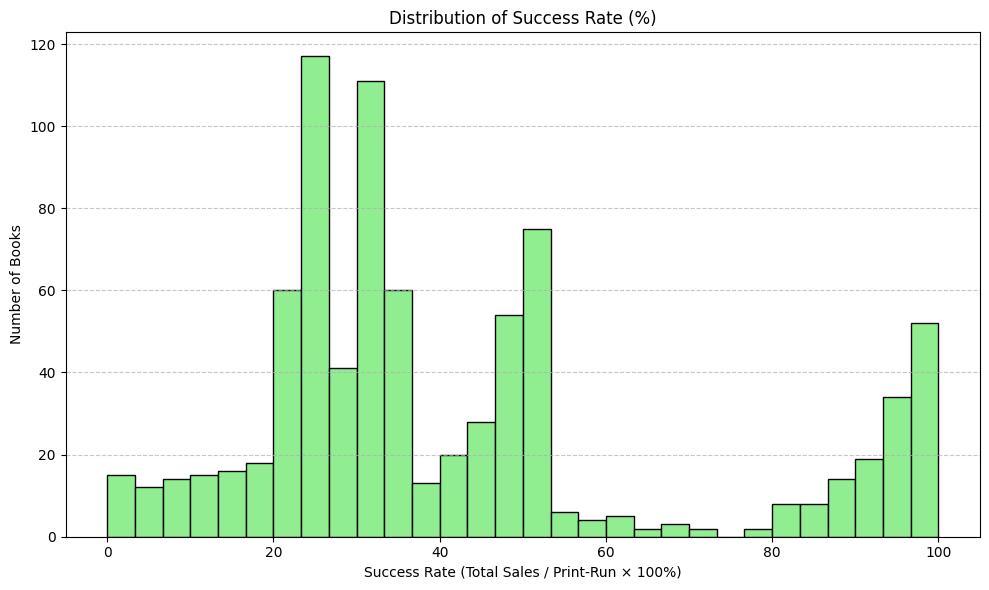

In [22]:
# Load dataset with success rates
df = pd.read_csv("final_books_for_classification.csv")

# # Calculate success rate
# df["Success_Rate"] = (df["Total_Sales"] / df["Тираж"]) * 100

# # Optional: filter out extreme or invalid values
# df = df[(df["Success_Rate"] >= 0) & (df["Success_Rate"] <= 100)]

# Plot histogram
plt.figure(figsize=(10, 6))
plt.hist(df["Success_Rate"], bins=30, color='lightgreen', edgecolor='black')
plt.title("Distribution of Success Rate (%)")
plt.xlabel("Success Rate (Total Sales / Print-Run × 100%)")
plt.ylabel("Number of Books")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


Monthly Book Sales Distribution with Holiday Markers

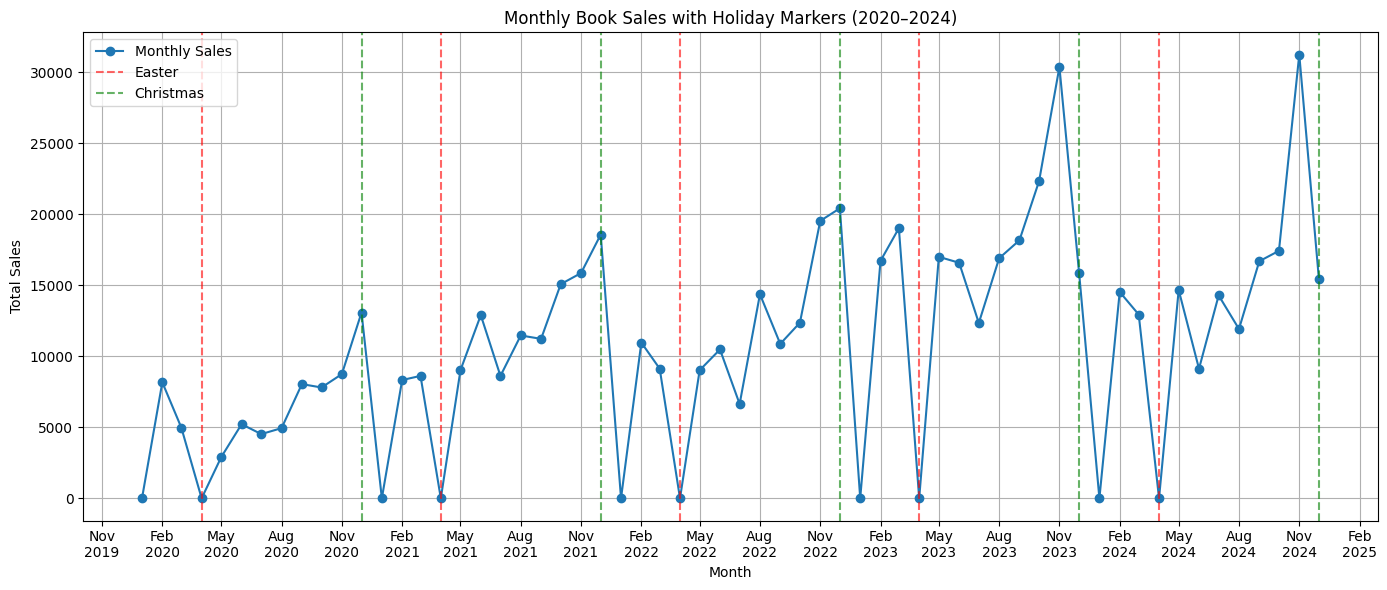

In [23]:
# Load dataset with all sales
df = pd.read_csv("book_sales_with_active_period.csv")
df["Date"] = pd.to_datetime(df["Date"])
monthly_sales = df.groupby("Date")["Sales"].sum()

# Create the plot
plt.figure(figsize=(14, 6))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o', label='Monthly Sales')
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))

# Add lines for holiday months (Easter - April, Christmas - December)
for year in range(2020, 2025):
    plt.axvline(pd.to_datetime(f"2020-04-01").replace(year=year), color='red', linestyle='--', alpha=0.6, label='Easter' if year == 2020 else "")
    plt.axvline(pd.to_datetime(f"2020-12-01").replace(year=year), color='green', linestyle='--', alpha=0.6, label='Christmas' if year == 2020 else "")
plt.title("Monthly Book Sales with Holiday Markers (2020–2024)")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

Distribution of Total Sales per Book

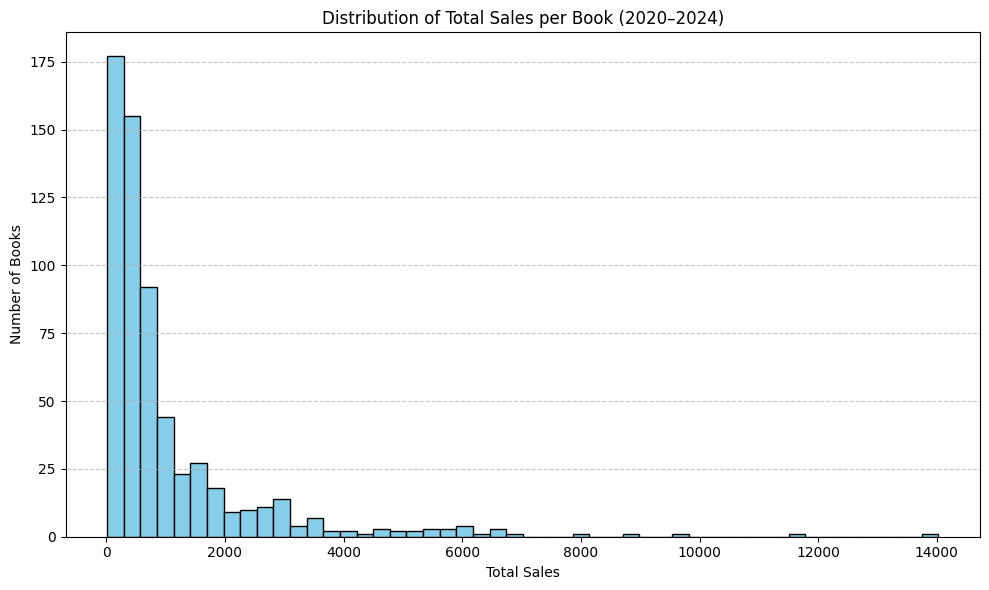

In [25]:
# Load dataset with all sales
df = pd.read_csv("book_sales_with_active_period.csv")

# Calculate total sales per book
total_sales_per_book = df.groupby("Title")["Sales"].sum()

# Create histogram
plt.figure(figsize=(10, 6))
plt.hist(total_sales_per_book, bins=50, color='skyblue', edgecolor='black')
plt.title("Distribution of Total Sales per Book (2020–2024)")
plt.xlabel("Total Sales")
plt.ylabel("Number of Books")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
